# Electricity Demand Forecasting

This notebook builds and evaluates time-series forecasting models for national electricity demand using historical demand, weather, and calendar features from the Kaggle **Electricity Load Forecasting** dataset.

## Objectives
- Build a simple baseline forecasting model using lag features
- Improve performance with temporal and weather features
- Compare multiple algorithms on the same train/test split
- Select the best-performing model based on Mean Absolute Error (MAE)

## Dataset
Source dataset: `saurabhshahane/electricity-load-forecasting`

Primary file used in this notebook: `continuous dataset.csv`


## 1. Setup and data loading

In [1]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

RANDOM_STATE = 42

In [2]:
# Download dataset from Kaggle
path = kagglehub.dataset_download("saurabhshahane/electricity-load-forecasting")
print("Dataset path:", path)
print("Available files:", os.listdir(path))

100%|██████████| 45.6M/45.6M [00:00<00:00, 99.3MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/saurabhshahane/electricity-load-forecasting/versions/1
Available files: ['train_dataframes.xlsx', 'weekly pre-dispatch forecast.csv', 'continuous dataset.csv', 'test_dataframes.xlsx']


In [3]:
# Load the main continuous time-series dataset
file_path = os.path.join(path, "continuous dataset.csv")
df = pd.read_csv(file_path)
df.head()

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


## 2. Dataset overview

### Column summary
- `datetime` — timestamp of each observation
- `nat_demand` — national electricity demand (target variable)
- `T2M_*` — temperature at 2 metres for different locations
- `QV2M_*` — humidity at 2 metres for different locations
- `TQL_*` — atmospheric moisture / cloud liquid content
- `W2M_*` — wind speed at 2 metres
- `Holiday_ID` — encoded holiday type
- `holiday` — holiday indicator
- `school` — school term indicator

For modelling, a subset of weather features is used to reduce redundancy and keep the model interpretable.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48048 entries, 0 to 48047
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    48048 non-null  object 
 1   nat_demand  48048 non-null  float64
 2   T2M_toc     48048 non-null  float64
 3   QV2M_toc    48048 non-null  float64
 4   TQL_toc     48048 non-null  float64
 5   W2M_toc     48048 non-null  float64
 6   T2M_san     48048 non-null  float64
 7   QV2M_san    48048 non-null  float64
 8   TQL_san     48048 non-null  float64
 9   W2M_san     48048 non-null  float64
 10  T2M_dav     48048 non-null  float64
 11  QV2M_dav    48048 non-null  float64
 12  TQL_dav     48048 non-null  float64
 13  W2M_dav     48048 non-null  float64
 14  Holiday_ID  48048 non-null  int64  
 15  holiday     48048 non-null  int64  
 16  school      48048 non-null  int64  
dtypes: float64(13), int64(3), object(1)
memory usage: 6.2+ MB


In [5]:
df.columns.tolist()

['datetime',
 'nat_demand',
 'T2M_toc',
 'QV2M_toc',
 'TQL_toc',
 'W2M_toc',
 'T2M_san',
 'QV2M_san',
 'TQL_san',
 'W2M_san',
 'T2M_dav',
 'QV2M_dav',
 'TQL_dav',
 'W2M_dav',
 'Holiday_ID',
 'holiday',
 'school']

## 3. Data preparation

The dataset is converted to a proper time-series format by:
1. parsing the timestamp column
2. sorting observations chronologically
3. setting `datetime` as the index

This preserves the temporal order needed for forecasting.


In [6]:
df["datetime"] = pd.to_datetime(df["datetime"])
df = df.sort_values("datetime").set_index("datetime")
df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
datetime,,,,,,,,,,,,,,,,
2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


## 4. Exploratory visualisation

This plot helps check whether demand shows visible seasonality, peaks, or repeating patterns over time.


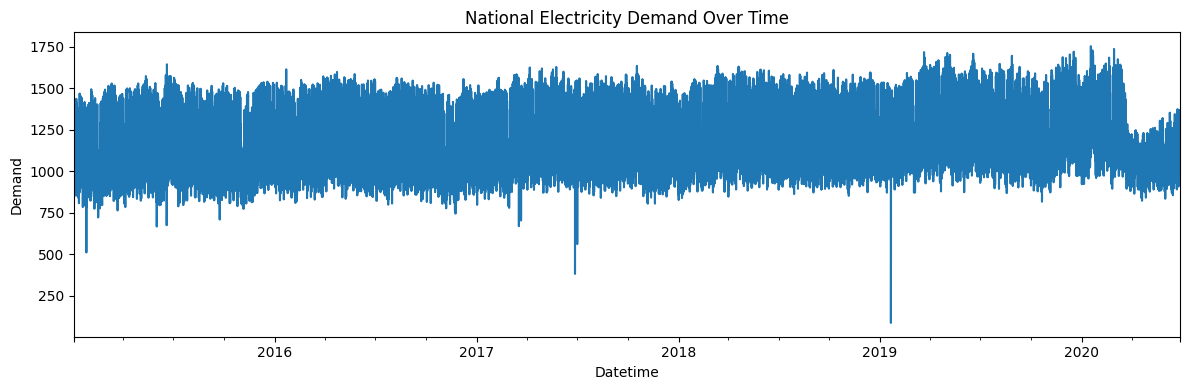

In [7]:
plt.figure(figsize=(12, 4))
df["nat_demand"].plot()
plt.title("National Electricity Demand Over Time")
plt.xlabel("Datetime")
plt.ylabel("Demand")
plt.tight_layout()
plt.show()

## 5. Feature engineering

### Lag features
Lag features allow the model to use past demand values when predicting future demand.

- `lag_1` — demand from the previous time step
- `lag_24` — demand from the same time on the previous day

These are useful because electricity demand usually has both short-term dependency and daily seasonality.


In [8]:
df["lag_1"] = df["nat_demand"].shift(1)
df["lag_24"] = df["nat_demand"].shift(24)

### Temporal and weather features

To improve forecasting performance, the following additional features are included:
- `hour` — captures within-day demand cycles
- `dayofweek` — captures weekday vs weekend behaviour
- `T2M_toc` — temperature
- `QV2M_toc` — humidity

A single-location subset of weather variables is used here as a simple, interpretable starting point.


In [9]:
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

# Drop rows made incomplete by lag creation
df = df.dropna()

df.head()

,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school,lag_1,lag_24,hour,dayofweek
datetime,,,,,,,,,,,,,,,,,,,,
2015-01-04 01:00:00,944.0556,25.681818,0.018494,0.003898,19.893350,23.627130,0.017540,0.006481,8.287433,22.533380,0.016747,0.085571,4.433089,0,0,0,968.0526,970.3450,1,6
2015-01-04 02:00:00,928.7193,25.602319,0.018486,0.004625,19.863871,23.477319,0.017448,0.003056,8.476267,22.360132,0.016609,0.084808,4.673439,0,0,0,944.0556,912.1755,2,6
2015-01-04 03:00:00,909.5566,25.572656,0.018448,0.008533,20.362023,23.369531,0.017387,0.001542,8.692403,22.244531,0.016510,0.082916,4.924833,0,0,0,928.7193,900.2688,3,6
2015-01-04 04:00:00,894.6543,25.547144,0.018409,0.008694,20.651574,23.281519,0.017326,0.001173,8.831439,22.148706,0.016411,0.084351,5.111986,0,0,0,909.5566,889.9538,4,6
2015-01-04 05:00:00,884.6659,25.527856,0.018402,0.008224,20.481538,23.207544,0.017265,0.002644,8.900692,22.074731,0.016349,0.089935,5.328663,0,0,0,894.6543,893.6865,5,6


## 6. Train/test split

Because this is a forecasting problem, the split is chronological:
- first 80% of observations for training
- last 20% for testing

This is more appropriate than random splitting because future values should never be used to predict the past.


In [10]:
baseline_features = ["lag_1", "lag_24"]
improved_features = ["lag_1", "lag_24", "hour", "dayofweek", "T2M_toc", "QV2M_toc"]

def chronological_split(dataframe, features, target="nat_demand", train_ratio=0.8):
    X = dataframe[features]
    y = dataframe[target]
    split_index = int(len(dataframe) * train_ratio)

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]
    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]
    return X_train, X_test, y_train, y_test

## 7. Baseline model: Random Forest with lag features only

Random Forest is used as a practical baseline because it handles non-linear relationships well and performs strongly on structured tabular data without heavy preprocessing.


In [11]:
X_train_base, X_test_base, y_train_base, y_test_base = chronological_split(df, baseline_features)

rf_baseline = RandomForestRegressor(random_state=RANDOM_STATE)
rf_baseline.fit(X_train_base, y_train_base)

rf_baseline_preds = rf_baseline.predict(X_test_base)
rf_baseline_mae = mean_absolute_error(y_test_base, rf_baseline_preds)

print(f"Baseline Random Forest MAE: {rf_baseline_mae:.2f}")

Baseline Random Forest MAE: 38.13


## 8. Improved model: Random Forest with lag, temporal, and weather features

This version tests whether adding temporal and weather context improves forecasting performance.


In [12]:
X_train, X_test, y_train, y_test = chronological_split(df, improved_features)

rf_model = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"Improved Random Forest MAE: {rf_mae:.2f}")

Improved Random Forest MAE: 19.09


In [13]:
improvement_pct = ((rf_baseline_mae - rf_mae) / rf_baseline_mae) * 100
print(f"MAE improvement from feature engineering: {improvement_pct:.1f}%")

MAE improvement from feature engineering: 49.9%


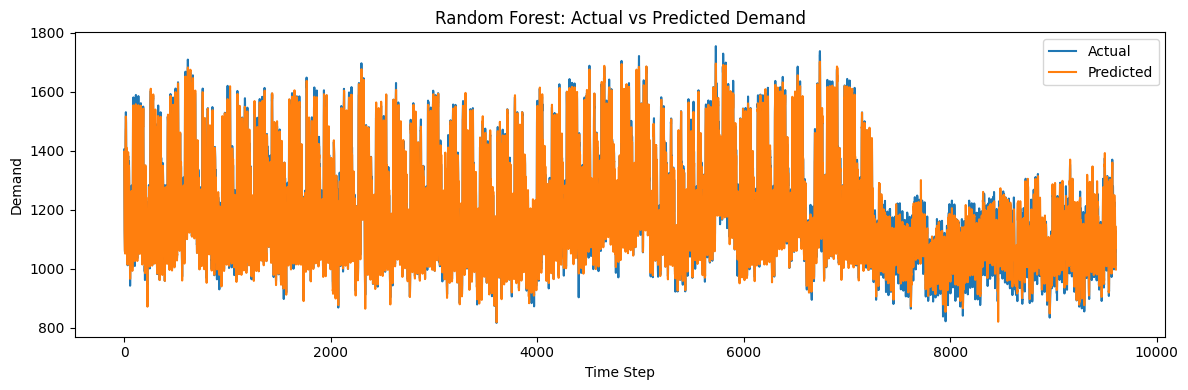

In [14]:
plt.figure(figsize=(12, 4))
plt.plot(y_test.values, label="Actual", linewidth=1.5)
plt.plot(rf_preds, label="Predicted", linewidth=1.5)
plt.title("Random Forest: Actual vs Predicted Demand")
plt.xlabel("Time Step")
plt.ylabel("Demand")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Model comparison

To assess whether Random Forest is the most suitable choice, it is compared with:
- **Linear Regression** — simple baseline
- **Gradient Boosting** — alternative tree-based ensemble method


In [15]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_preds)

gb_model = GradientBoostingRegressor(random_state=RANDOM_STATE)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_preds)

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [lr_mae, rf_mae, gb_mae]
}).sort_values("MAE")

results

,Model,MAE
1,Random Forest,19.094952
2,Gradient Boosting,20.479888
0,Linear Regression,37.059296


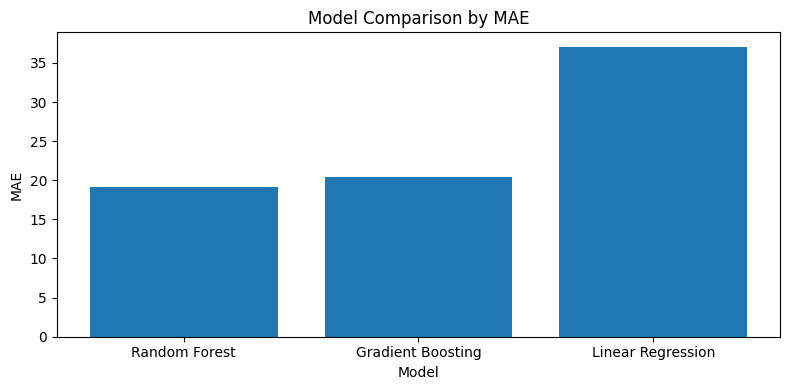

In [16]:
plt.figure(figsize=(8, 4))
plt.bar(results["Model"], results["MAE"])
plt.title("Model Comparison by MAE")
plt.ylabel("MAE")
plt.xlabel("Model")
plt.tight_layout()
plt.show()

## 10. Feature importance

Feature importance from the best-performing Random Forest model helps identify which inputs contributed most to prediction quality.


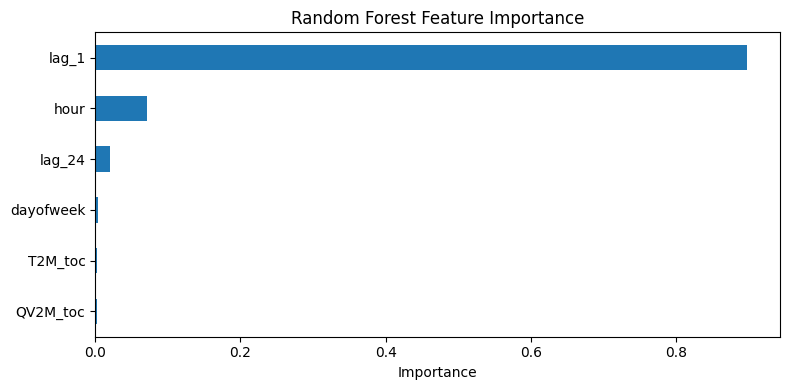

In [17]:
feature_importance = pd.Series(rf_model.feature_importances_, index=improved_features).sort_values()

plt.figure(figsize=(8, 4))
feature_importance.plot(kind="barh")
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## 11. Key findings

- Adding temporal and weather features reduced MAE substantially compared with the lag-only baseline.
- Linear Regression performed worst, suggesting that the forecasting problem contains non-linear relationships.
- Random Forest achieved the best result, slightly outperforming Gradient Boosting on this feature set.
- Additional weekly lag experimentation was explored during development, but it did not improve performance in the tested setup.

## 12. Conclusion

This project demonstrates that electricity demand forecasting benefits from a combination of:
- historical demand signals
- temporal context
- weather information

Among the tested models, **Random Forest** produced the lowest MAE and provided the best balance of performance and simplicity for this dataset.

## Next steps
Potential improvements include:
- systematic hyperparameter tuning
- broader weather feature selection across locations
- time-series cross-validation
- comparison against external benchmark forecasts
